In [1]:
ROOT =  '/kaggle/input/datasets/manojkumarcs28/plantdoc-dataset/PlantDoc/'
TEST = ROOT + 'test'
TRAIN = ROOT + 'test'

We want to use ResNext image embeddings for EDA and classification, so let's add some code to get those for us.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 155MB/s]


Let's load up our data. We don't have a lot, so this only takes a couple of minutes.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (64, 64)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except: 
        print(filename)
        return None


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'])
        for index, input_file in enumerate(list(iglob(pathname=arg))) ]
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TRAIN + '/*') if isdir(folder)}
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in tqdm.tqdm(desc='train classes', iterable=train_dict.items())]))
test_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TEST + '/*') if isdir(folder)}
test_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in tqdm.tqdm(desc='test classes', iterable=test_dict.items())]))
print('done in {}'.format(arrow.now() - time_start))

test classes: 100%|██████████| 27/27 [00:39<00:00,  1.48s/it]

done in 0:01:22.147279


We have a lot of classes. Are they balanced?

In [4]:
train_df['tag'].value_counts(normalize=False).to_frame().T

tag,Corn leaf blight,grape leaf,Tomato Septoria leaf spot,Blueberry leaf,Apple rust leaf,Corn rust leaf,Apple Scab Leaf,Tomato leaf mosaic virus,Cherry leaf,Tomato leaf late blight,...,Strawberry leaf,Soyabean leaf,Bell_pepper leaf,Potato leaf early blight,grape leaf black rot,Raspberry leaf,Squash Powdery mildew leaf,Tomato mold leaf,Tomato leaf yellow virus,Corn Gray leaf spot
count,12,12,11,11,10,10,10,10,10,10,...,8,8,8,8,8,7,6,6,6,4


How about our test data?

In [5]:
test_df['tag'].value_counts(normalize=False).to_frame().T

tag,Corn leaf blight,grape leaf,Tomato Septoria leaf spot,Blueberry leaf,Apple rust leaf,Corn rust leaf,Apple Scab Leaf,Tomato leaf mosaic virus,Cherry leaf,Tomato leaf late blight,...,Strawberry leaf,Soyabean leaf,Bell_pepper leaf,Potato leaf early blight,grape leaf black rot,Raspberry leaf,Squash Powdery mildew leaf,Tomato mold leaf,Tomato leaf yellow virus,Corn Gray leaf spot
count,12,12,11,11,10,10,10,10,10,10,...,8,8,8,8,8,7,6,6,6,4


Let's use TSNE to add x/y coordinates so we can build an exploratory plot.

In [6]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))
test_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
test_df[['x', 'y']] = test_reducer.fit_transform(X=test_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 236 samples in 0.002s...
[t-SNE] Computed neighbors for 236 samples in 0.062s...
[t-SNE] Computed conditional probabilities for sample 236 / 236
[t-SNE] Mean sigma: 4.573064
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.671326
[t-SNE] KL divergence after 1000 iterations: 0.845070
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 236 samples in 0.001s...
[t-SNE] Computed neighbors for 236 samples in 0.015s...
[t-SNE] Computed conditional probabilities for sample 236 / 236
[t-SNE] Mean sigma: 4.573064
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.671326
[t-SNE] KL divergence after 1000 iterations: 0.845070


Let's plot.

In [7]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: plant doc', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=8, color=mapper)
show(plot_figure)

Loading BokehJS ...

This plot looks pretty sparse, and we see a lot of class mixing. We should probably have modest expectations regarding our model accuracy. Let's build a model and see what happens.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

logreg = LogisticRegression(max_iter=1000, tol=1e-12).fit(train_df['value'].apply(func=pd.Series), train_df['tag'])
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print(classification_report(zero_division=0.0, y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series))))

model fit in 699 iterations
accuracy: 1.0000
f1: 1.0000
                            precision    recall  f1-score   support

           Apple Scab Leaf       1.00      1.00      1.00        10
                Apple leaf       1.00      1.00      1.00         9
           Apple rust leaf       1.00      1.00      1.00        10
          Bell_pepper leaf       1.00      1.00      1.00         8
     Bell_pepper leaf spot       1.00      1.00      1.00         9
            Blueberry leaf       1.00      1.00      1.00        11
               Cherry leaf       1.00      1.00      1.00        10
       Corn Gray leaf spot       1.00      1.00      1.00         4
          Corn leaf blight       1.00      1.00      1.00        12
            Corn rust leaf       1.00      1.00      1.00        10
                Peach leaf       1.00      1.00      1.00         9
  Potato leaf early blight       1.00      1.00      1.00         8
   Potato leaf late blight       1.00      1.00      1.00  

It's odd to see such great f1 scores with a TSNE plot like that. What do our model probabilities look like?

<Axes: xlabel='probability', ylabel='Count'>

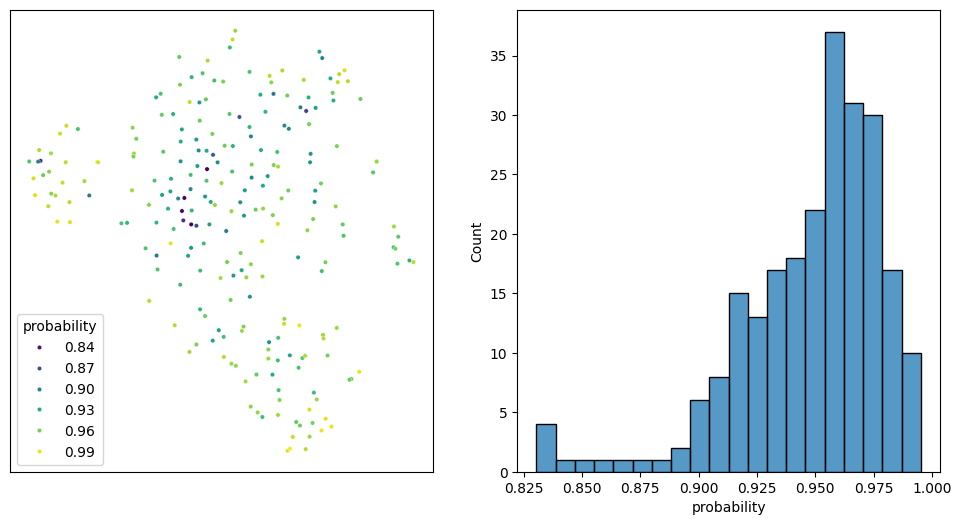

In [9]:
import matplotlib.pyplot as plt
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = test_df[['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=test_df['value'].apply(func=pd.Series)), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=10)
ax[0].set(xlabel=None)
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)

Our model probabilities are great for so many classes. Hmmm.